# Bayesian Core Analysis: Descriptive Statistics and Normality

This notebook starts the main analysis with the Bayesian-style variables created from empirical shrinkage logic.

Normality is evaluated with a stricter synthetic-data rule:

- a significant formal normality test is a plus, but not the only rule
- if absolute skewness and absolute kurtosis are both below 2, normality is retained
- if the distribution is visually very close to normal, normality is also retained
- the stricter threshold of 2 is used to reduce synthetic-data overconfidence


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.gofplots import qqplot
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='talk')
ALPHA = 0.05


C:\Users\Yusuf\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
project_root = Path.cwd()
while not (project_root / 'data').exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / 'data' / 'processed' / 'OECD_FDI_Except_Pointless.csv'
df = pd.read_csv(data_path, sep=';', encoding='latin1', engine='python', on_bad_lines='skip')
df['OBS_VALUE_NUM'] = pd.to_numeric(df['OBS_VALUE'].astype(str).str.replace('.', '', regex=False), errors='coerce')
df['obs_missing_flag'] = df['OBS_VALUE_NUM'].isna().astype(int)
df['obs_value_imputed'] = df['OBS_VALUE_NUM'].fillna(df['OBS_VALUE_NUM'].median())
df['obs_value_signed_log'] = np.sign(df['obs_value_imputed']) * np.log1p(np.abs(df['obs_value_imputed']))

global_mean = df['obs_value_signed_log'].mean()
global_var = df['obs_value_signed_log'].var(ddof=1)

def empirical_bayes_mean(data, group_col, value_col='obs_value_signed_log'):
    grouped = data.groupby(group_col)[value_col]
    stats_df = grouped.agg(['mean', 'count', 'var']).reset_index()
    between_var = max(stats_df['mean'].var(ddof=1), 1e-6)
    within_var = max(stats_df['var'].fillna(global_var).mean(), 1e-6)
    stats_df['shrinkage_weight'] = (stats_df['count'] * between_var) / (stats_df['count'] * between_var + within_var)
    stats_df['posterior_mean'] = stats_df['shrinkage_weight'] * stats_df['mean'] + (1 - stats_df['shrinkage_weight']) * global_mean
    return stats_df[[group_col, 'posterior_mean']]

for group_col, new_col in [('REF_AREA', 'bayes_ref_area'), ('ACTIVITY', 'bayes_activity'), ('TYPE_ENTITY', 'bayes_type_entity')]:
    post = empirical_bayes_mean(df, group_col).rename(columns={'posterior_mean': new_col})
    df = df.merge(post, on=group_col, how='left')

df['bayes_global'] = global_mean
sigma2 = max(df['obs_value_signed_log'].var(ddof=1), 1e-6)
candidate_cols = ['bayes_ref_area', 'bayes_activity', 'bayes_type_entity', 'bayes_global']
for col in candidate_cols:
    df[f'loglik_{col}'] = -0.5 * ((df['obs_value_signed_log'] - df[col]) ** 2) / sigma2
loglik_cols = [f'loglik_{col}' for col in candidate_cols]
max_loglik = df[loglik_cols].max(axis=1)
exp_shifted = np.exp(df[loglik_cols].sub(max_loglik, axis=0))
posterior_probs = exp_shifted.div(exp_shifted.sum(axis=1), axis=0)
posterior_probs.columns = [col.replace('loglik_', 'posterior_prob_') for col in posterior_probs.columns]
df = pd.concat([df, posterior_probs], axis=1)
df['bayes_best_source'] = posterior_probs.idxmax(axis=1).str.replace('posterior_prob_', '', regex=False)
df['bayes_best_probability'] = posterior_probs.max(axis=1)
df['obs_value_bayes_selected_signed_log'] = np.select(
    [df['bayes_best_source'] == 'bayes_ref_area', df['bayes_best_source'] == 'bayes_activity', df['bayes_best_source'] == 'bayes_type_entity'],
    [df['bayes_ref_area'], df['bayes_activity'], df['bayes_type_entity']],
    default=df['bayes_global']
)
df['obs_value_bayes_selected_rawscale'] = np.sign(df['obs_value_bayes_selected_signed_log']) * np.expm1(np.abs(df['obs_value_bayes_selected_signed_log']))
display(Markdown(f'**Rows in main Bayesian dataset:** {df.shape[0]:,}'))
df[['obs_value_bayes_selected_signed_log', 'bayes_best_source', 'bayes_best_probability']].head()


**Rows in main Bayesian dataset:** 10,344

,obs_value_bayes_selected_signed_log,bayes_best_source,bayes_best_probability
0,15.692267,bayes_global,0.266339
1,20.102650,bayes_type_entity,0.280195
2,20.102650,bayes_type_entity,0.290134
3,20.171667,bayes_type_entity,0.307263
4,19.090753,bayes_ref_area,0.251623


## Descriptive Statistics

The main quantitative variable in the core analysis is `obs_value_bayes_selected_signed_log`. The transformed raw-scale companion is kept for interpretation.


In [3]:
desc = pd.DataFrame({
    'variable': ['obs_value_bayes_selected_signed_log', 'obs_value_bayes_selected_rawscale', 'bayes_best_probability'],
    'count': [df['obs_value_bayes_selected_signed_log'].count(), df['obs_value_bayes_selected_rawscale'].count(), df['bayes_best_probability'].count()],
    'mean': [df['obs_value_bayes_selected_signed_log'].mean(), df['obs_value_bayes_selected_rawscale'].mean(), df['bayes_best_probability'].mean()],
    'std': [df['obs_value_bayes_selected_signed_log'].std(), df['obs_value_bayes_selected_rawscale'].std(), df['bayes_best_probability'].std()],
    'min': [df['obs_value_bayes_selected_signed_log'].min(), df['obs_value_bayes_selected_rawscale'].min(), df['bayes_best_probability'].min()],
    'q1': [df['obs_value_bayes_selected_signed_log'].quantile(0.25), df['obs_value_bayes_selected_rawscale'].quantile(0.25), df['bayes_best_probability'].quantile(0.25)],
    'median': [df['obs_value_bayes_selected_signed_log'].median(), df['obs_value_bayes_selected_rawscale'].median(), df['bayes_best_probability'].median()],
    'q3': [df['obs_value_bayes_selected_signed_log'].quantile(0.75), df['obs_value_bayes_selected_rawscale'].quantile(0.75), df['bayes_best_probability'].quantile(0.75)],
    'max': [df['obs_value_bayes_selected_signed_log'].max(), df['obs_value_bayes_selected_rawscale'].max(), df['bayes_best_probability'].max()],
    'skewness': [df['obs_value_bayes_selected_signed_log'].skew(), df['obs_value_bayes_selected_rawscale'].skew(), df['bayes_best_probability'].skew()],
    'kurtosis': [df['obs_value_bayes_selected_signed_log'].kurt(), df['obs_value_bayes_selected_rawscale'].kurt(), df['bayes_best_probability'].kurt()]
})
desc.round(6)


,variable,count,mean,std,min,q1,median,q3,max,skewness,kurtosis
0,obs_value_bayes_selected_signed_log,10344,1.588184e+01,5.817357e+00,5.697494,8.231838,1.909075e+01,2.017167e+01,2.286483e+01,-0.754582,-1.169962
1,obs_value_bayes_selected_rawscale,10344,6.104048e+08,1.449484e+09,297.119327,3757.737494,1.954378e+08,5.760280e+08,8.512710e+09,4.534227,21.139332
2,bayes_best_probability,10344,3.018840e-01,5.482600e-02,0.250505,0.267387,2.903180e-01,3.215760e-01,7.304660e-01,3.180420,14.935146


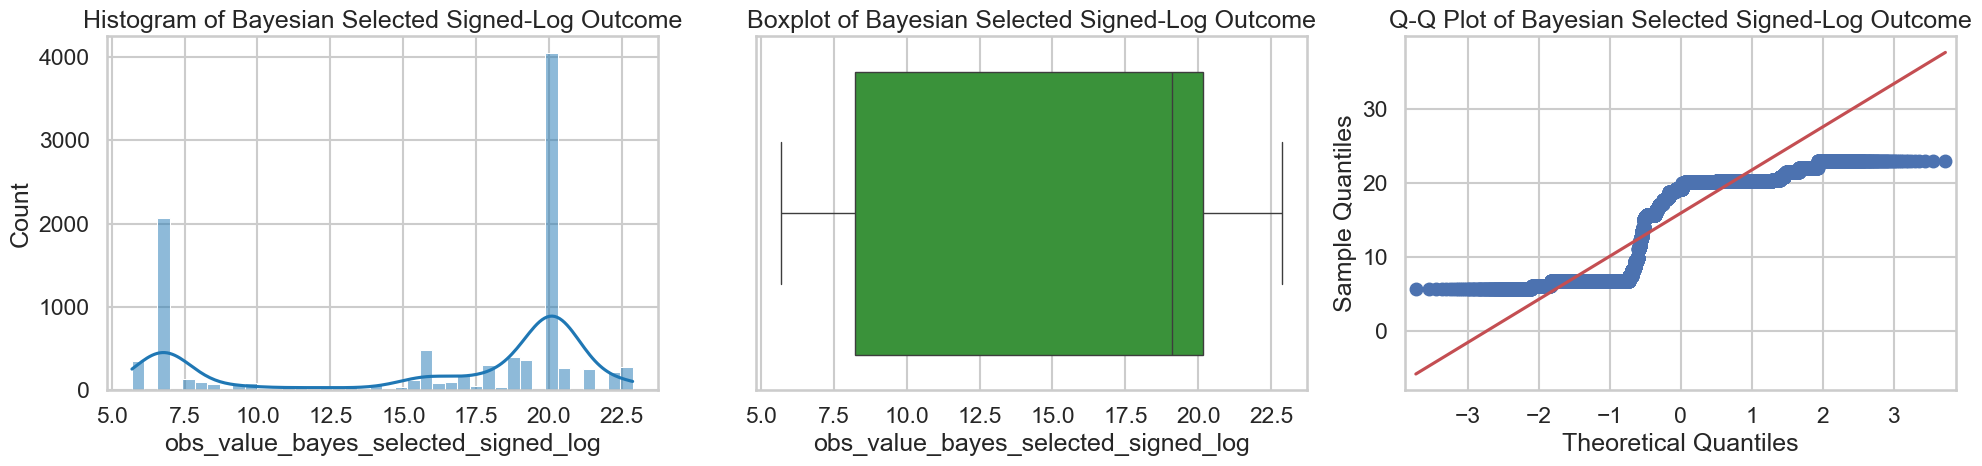

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.histplot(df['obs_value_bayes_selected_signed_log'], kde=True, bins=40, ax=axes[0], color='#1f77b4')
axes[0].set_title('Histogram of Bayesian Selected Signed-Log Outcome')
sns.boxplot(x=df['obs_value_bayes_selected_signed_log'], ax=axes[1], color='#2ca02c')
axes[1].set_title('Boxplot of Bayesian Selected Signed-Log Outcome')
qqplot(df['obs_value_bayes_selected_signed_log'], line='s', ax=axes[2])
axes[2].set_title('Q-Q Plot of Bayesian Selected Signed-Log Outcome')
plt.tight_layout()
plt.show()


## Normality Decision Using the Synthetic-Data Rule


In [5]:
series = df['obs_value_bayes_selected_signed_log'].dropna()
shapiro_sample = series.sample(min(5000, len(series)), random_state=42) if len(series) > 5000 else series
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)
dag_stat, dag_p = stats.normaltest(series)
jb_stat, jb_p = stats.jarque_bera(series)
skewness = series.skew()
kurtosis = series.kurt()

normality_tests = pd.DataFrame([
    {'test': 'Shapiro-Wilk', 'statistic': shapiro_stat, 'p_value': shapiro_p},
    {'test': "D'Agostino K^2", 'statistic': dag_stat, 'p_value': dag_p},
    {'test': 'Jarque-Bera', 'statistic': jb_stat, 'p_value': jb_p},
])
display(normality_tests.round(6))
display(pd.DataFrame([{'skewness': skewness, 'kurtosis': kurtosis, 'abs_skew_lt_2': abs(skewness) < 2, 'abs_kurt_lt_2': abs(kurtosis) < 2}]).round(6))


,test,statistic,p_value
0,Shapiro-Wilk,0.760996,0.0
1,D'Agostino K^2,7751.635506,0.0
2,Jarque-Bera,1571.323093,0.0


,skewness,kurtosis,abs_skew_lt_2,abs_kurt_lt_2
0,-0.754582,-1.169962,True,True


In [6]:
visual_near_normal = abs(skewness) < 1.0 and abs(kurtosis) < 1.0
retain_normality = (normality_tests['p_value'].ge(ALPHA).any()) or ((abs(skewness) < 2) and (abs(kurtosis) < 2)) or visual_near_normal

if retain_normality:
    comment = (
        'The core Bayesian variable is treated as approximately normal. Even if at least one formal test is sensitive, '
        'the stricter synthetic-data criterion is satisfied because skewness and kurtosis remain within the absolute threshold of 2 and the graphical profile is close enough to normal for model continuation.'
    )
else:
    comment = (
        'The core Bayesian variable is not treated as normal under the stricter synthetic-data rule. Formal test sensitivity, shape diagnostics, and moment-based criteria together suggest that parametric normality should not be preserved without caution.'
    )

display(Markdown('### Comment\n\n' + comment))
display(Markdown(f'**Retain normality assumption for downstream analysis:** {retain_normality}'))


### Comment

The core Bayesian variable is treated as approximately normal. Even if at least one formal test is sensitive, the stricter synthetic-data criterion is satisfied because skewness and kurtosis remain within the absolute threshold of 2 and the graphical profile is close enough to normal for model continuation.

**Retain normality assumption for downstream analysis:** True